##### I watched and practiced Reza Shokrzad Data Visualization course
##### https://www.youtube.com/watch?v=8RGJPXgDIG4
##### https://github.com/rezashokrzad/Youtube_2023/blob/main/Data%20Visualization.pdf

# Main Charts in Data Analysis

## Data Exploratory

In [288]:
import urllib.request

url = "https://raw.githubusercontent.com/Njmondoa/Superstore-Sales-Analysis/main/SuperStore_data.csv"
urllib.request.urlretrieve(url, "SuperStore_data.csv")

('SuperStore_data.csv', <http.client.HTTPMessage at 0x21e1588b110>)

In [289]:
# load and read the dataset
import pandas as pd
df = pd.read_csv('SuperStore_data.csv')

In [290]:
df.shape

(10296, 21)

In [291]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [292]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10296 entries, 0 to 10295
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10296 non-null  str    
 1   Order ID       10296 non-null  str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       99

## Pie Chart

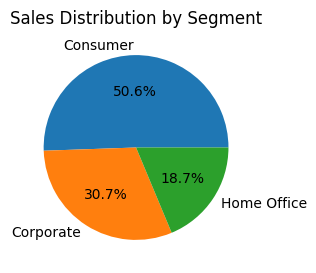

In [293]:
import matplotlib.pyplot as plt

# Calculate total sales for each segment
sales_by_segment = df.groupby('Segment')['Sales'].sum()

# Create pie chart
plt.figure(figsize=(3, 3), dpi=100)
plt.pie(sales_by_segment, labels=sales_by_segment.index, autopct='%1.1f%%')
plt.title('Sales Distribution by Segment')
plt.show()

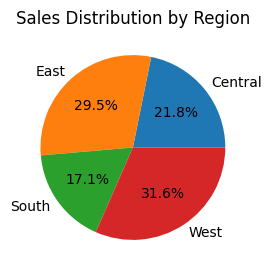

In [294]:
# Calculate total sales for each region
sales_by_region = df.groupby('Region')['Sales'].sum()

# Create pie chart
plt.figure(figsize=(3, 3), dpi=100)
plt.pie(sales_by_region, labels=sales_by_region.index, autopct='%1.1f%%')
plt.title('Sales Distribution by Region')
plt.show()

## Bar Chart | Clustered Bar Chart | Stacked Bar Chart

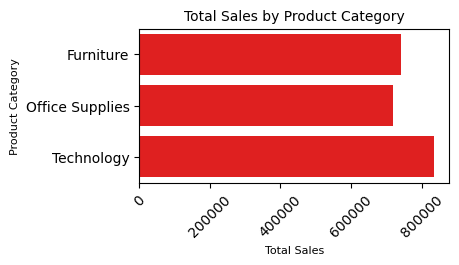

In [295]:
from numpy import size
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total sales for each category
sales_by_category = df.groupby('Category')['Sales'].sum()

# Create horizontal bar chart
plt.figure(figsize=(4, 2), dpi=100)
sns.barplot(x=sales_by_category.values, y=sales_by_category.index, orient='h', color="Red")
plt.xticks(rotation=45)
plt.xlabel('Total Sales', size=8)
plt.ylabel('Product Category', size=8)
plt.title('Total Sales by Product Category', size=10)
plt.show()

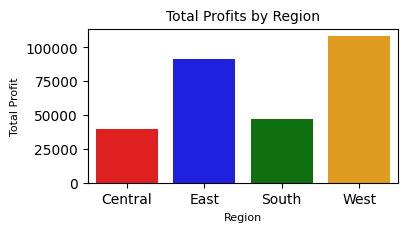

In [296]:
# Calculate total profits for each region
profits_by_region = df.groupby('Region')['Profit'].sum()

# Create vertical bar chart
plt.figure(figsize=(4, 2), dpi=100)
sns.barplot(x=profits_by_region.index, y=profits_by_region.values, orient='v', \
            palette=['red', 'blue', 'green', 'orange'], hue=profits_by_region.index, legend=False)
plt.xlabel('Region', size=8)
plt.ylabel('Total Profit', size=8)
plt.title('Total Profits by Region', size=10)
plt.show()

In [297]:
# Calculate total sales and profits for each category
sales_and_profits_by_category = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
# Melt the data
melted_data = pd.melt(sales_and_profits_by_category, id_vars="Category", value_name="Total", var_name="Type")

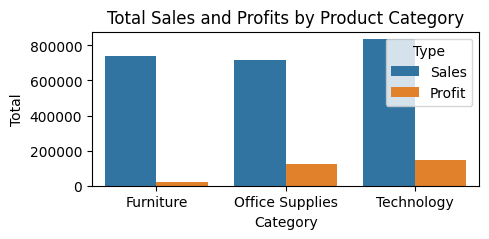

In [298]:
plt.figure(figsize=(5, 2), dpi=100)
sns.barplot(x='Category', y='Total', hue='Type', data=melted_data)
plt.title('Total Sales and Profits by Product Category')
plt.show()

In [299]:
df.groupby(['Region', 'Segment'])['Sales'].sum()

Region   Segment    
Central  Consumer       252031.4340
         Corporate      157995.8128
         Home Office     91212.6440
East     Consumer       350908.1670
         Corporate      200409.3470
         Home Office    127463.7260
South    Consumer       195580.9710
         Corporate      121885.9325
         Home Office     74255.0015
West     Consumer       362880.7730
         Corporate      225855.2745
         Home Office    136721.7770
Name: Sales, dtype: float64

In [300]:
# reset_index adds index values to all rows
df.groupby(['Region', 'Segment'])['Sales'].sum().reset_index()

,Region,Segment,Sales
0,Central,Consumer,252031.4340
1,Central,Corporate,157995.8128
2,Central,Home Office,91212.6440
3,East,Consumer,350908.1670
4,East,Corporate,200409.3470
5,East,Home Office,127463.7260
6,South,Consumer,195580.9710
7,South,Corporate,121885.9325
8,South,Home Office,74255.0015
9,West,Consumer,362880.7730


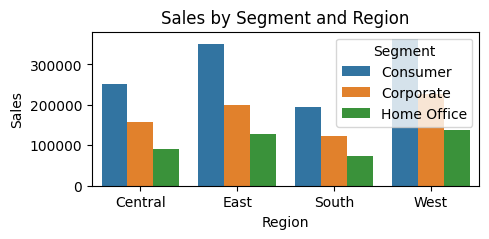

In [301]:
# Calculate total sales for each segment in each region
sales_by_region_segment = df.groupby(['Region', 'Segment'])['Sales'].sum().reset_index()

plt.figure(figsize=(5, 2), dpi=100)
sns.barplot(x='Region', y='Sales', hue='Segment', data=sales_by_region_segment)
plt.title('Sales by Segment and Region')
plt.show()

In [302]:
# unstack() creates a data frame which each groupby values to one axis 
df.groupby(['Region', 'Segment'])['Sales'].sum().unstack()

Segment,Consumer,Corporate,Home Office
Region,,,
Central,252031.434,157995.8128,91212.6440
East,350908.167,200409.3470,127463.7260
South,195580.971,121885.9325,74255.0015
West,362880.773,225855.2745,136721.7770


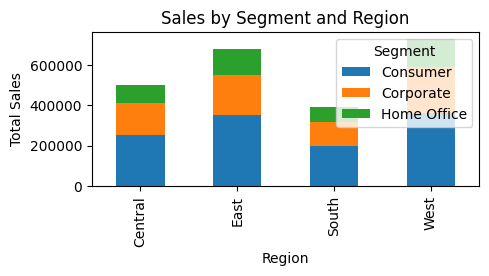

In [303]:
# Calculate total sales for each segment in each region
sales_by_region_segment = df.groupby(['Region', 'Segment'])['Sales'].sum().unstack()
sales_by_region_segment.plot(kind='bar', stacked=True, figsize=(5, 2))
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.title('Sales by Segment and Region')
plt.show()

## Histogram

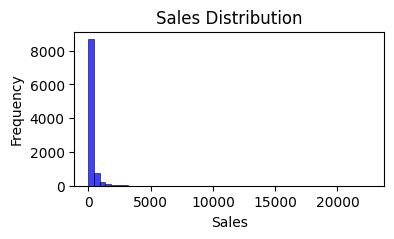

In [304]:
plt.figure(figsize=(4, 2), dpi=100)
sns.histplot(df['Sales'], bins=50, kde=False, color='blue')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

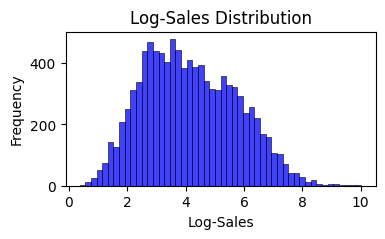

In [305]:
import numpy as np
plt.figure(figsize=(4, 2), dpi=100)
sns.histplot(np.log1p(df['Sales']), bins=50, kde=False, color='blue')
plt.title('Log-Sales Distribution')
plt.xlabel('Log-Sales')
plt.ylabel('Frequency')
plt.show()

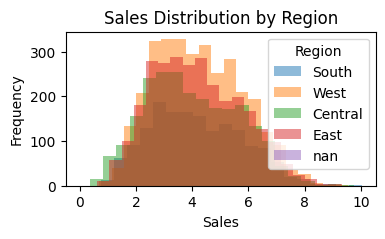

In [306]:
# Plot a histogram of sales for each region
plt.figure(figsize=(4, 2), dpi=100)
regions = df['Region'].unique()  # Get unique regions from the dataset

# Iterate over each region and plot a histogram
for region in regions:
    region_sales = df[df['Region'] == region]['Sales']  # Filter sales data for the current region
    plt.hist(np.log1p(region_sales), bins=20, alpha=0.5, label=region)  # Plot histogram for the current region

plt.title('Sales Distribution by Region')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.legend(title='Region')
plt.show()

## Line Chart

In [307]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


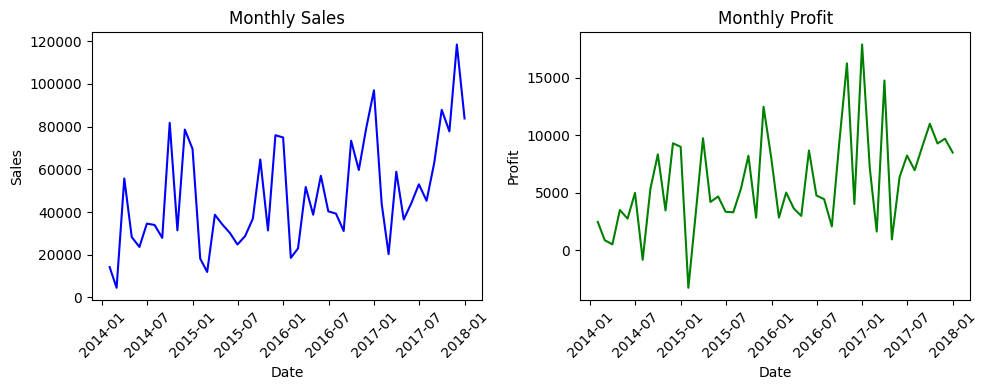

In [308]:
# Convert 'Order Date' to datetime
df_copy = df.copy()
df_copy['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')

# Set 'Order Date' as index
df_copy.set_index('Order Date', inplace=True)

# Resample by month and sum sales and profit
monthly_data = df_copy.resample('ME').sum()

# Create figure and axes
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Plot sales
ax[0].plot(monthly_data.index, monthly_data['Sales'], color='blue')
ax[0].set_title('Monthly Sales')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Sales')
ax[0].tick_params(axis='x', rotation=45)

# Plot profit
ax[1].plot(monthly_data.index, monthly_data['Profit'], color='green')
ax[1].set_title('Monthly Profit')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Profit')
ax[1].tick_params(axis='x', rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

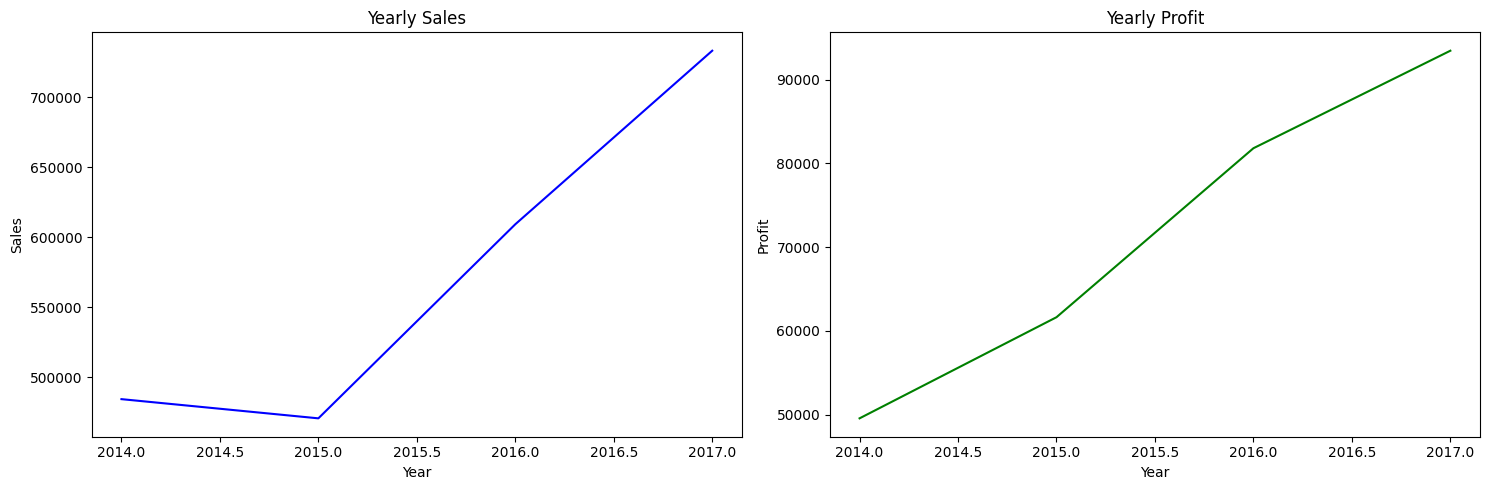

In [309]:
# Resample by year and sum sales and profit
yearly_data = df_copy.resample('YE').sum()

# Create figure and axes
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Plot sales
ax[0].plot(yearly_data.index.year, yearly_data['Sales'], color='blue')
ax[0].set_title('Yearly Sales')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Sales')

# Plot profit
ax[1].plot(yearly_data.index.year, yearly_data['Profit'], color='green')
ax[1].set_title('Yearly Profit')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Profit')

# Show the plot
plt.tight_layout()
plt.show()

## Scatter Plot

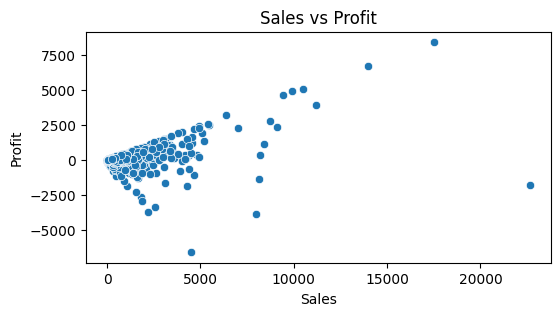

In [310]:
plt.figure(figsize=(6, 3), dpi=100)
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

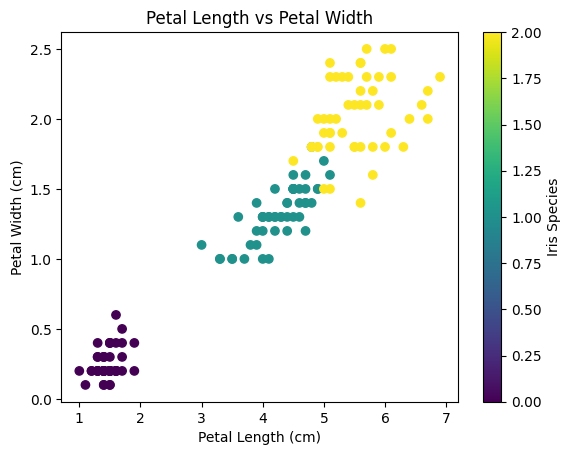

In [314]:
from sklearn.datasets import load_iris
data = load_iris()
print(data)
# Extract the features (petal length and width)
petal_length = data.data[:, 2]  # Column index 2 corresponds to petal length
petal_width = data.data[:, 3]   # Column index 3 corresponds to petal width
labels = data.target            # Labels of the iris species

# Create a scatter plot
plt.scatter(petal_length, petal_width, c=labels, cmap='viridis')

# Add labels and title to the plot
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Petal Length vs Petal Width')

# Show the plot
plt.colorbar(label='Iris Species')
plt.show()

## BoxPlot

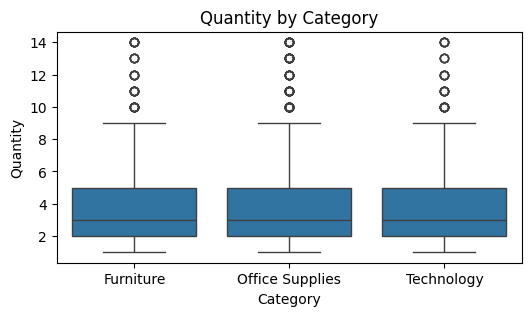

In [312]:
plt.figure(figsize=(6, 3), dpi=100)
sns.boxplot(x='Category', y='Quantity', data=df)
plt.title('Quantity by Category')
plt.xlabel('Category')
plt.ylabel('Quantity')
plt.show()


C:\Users\Sepahrad\AppData\Local\Temp\ipykernel_7928\2170888962.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(X, labels=data.feature_names)


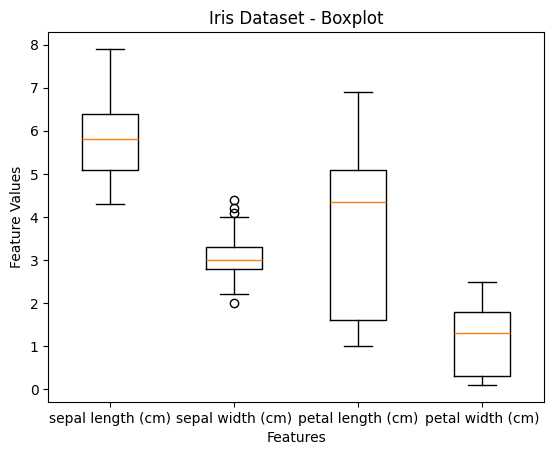

In [313]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load the Iris dataset
data = load_iris()
X = data.data

# Create a boxplot
plt.boxplot(X, labels=data.feature_names)

# Add labels and title to the plot
plt.xlabel('Features')
plt.ylabel('Feature Values')
plt.title('Iris Dataset - Boxplot')

# Show the plot
plt.show()
